# Stating a magnetic texture

Not every magnet is described by one number per atom. In a helix, a canted
antiferromagnet or a 120 degree Neel state each atom carries a moment pointing
in its own direction, and no single axis describes the set. This notebook states
such a texture atom by atom, converges it, and then asks the question that
actually matters afterwards: is it still there?

The cell is four hydrogen atoms in a line 5 bohr apart, each moment turned 90
degrees from the one before in the plane perpendicular to the chain. The four
directions are given one per atom in a `STARTING_MOMENTS` card, which is the only
way four atoms of the same species can carry four different directions.

At convergence every site holds **0.4675 $\mu_B$** and the neighbour angles are
**90.00 degrees**, while the magnetization of the cell as a whole comes to
1.6e-5 $\mu_B$. A compensated magnet is invisible in the total, and the per-site
numbers are the only place it shows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

calc = Calculator.from_file('../tests/data/qe/h4-cycloid-90.in',
                            pseudo_dir='../tests/data/pseudo')
result = calc.get_scf()
moments = np.array(result.site_moments)
print(f'total energy {result.total_energy:.10f} Ry in {result.iterations} iterations')
for site, m in enumerate(moments, start=1):
    turn = np.degrees(np.arctan2(m[1], m[0])) % 360.0
    print(f'   site {site}   |m| = {np.linalg.norm(m):.4f} mu_B'
          f'   pointing at {turn:6.2f} degrees')

total energy -3.8187943769 Ry in 9 iterations
   site 1   |m| = 0.4675 mu_B   pointing at   0.00 degrees
   site 2   |m| = 0.4675 mu_B   pointing at  90.00 degrees
   site 3   |m| = 0.4675 mu_B   pointing at 180.00 degrees
   site 4   |m| = 0.4675 mu_B   pointing at 270.00 degrees


## What the cell total says, and what it misses

Every magnetic calculation reports the magnetization integrated over the cell.
Here that number is zero, because four moments 90 degrees apart cancel exactly.
The same zero comes out of an antiferromagnet, out of a spiral, and out of a cell
whose magnetism has collapsed to nothing at all.

What separates those cases is the moment inside a sphere around each nucleus,
which is also the quantity a neutron experiment is sensitive to.

In [2]:
cell_total = np.linalg.norm(result.magnetization_vector)
print(f'magnetization of the whole cell   {cell_total:.2e} mu_B')
print(f'moment on each site               {np.linalg.norm(moments, axis=1).mean():.4f} mu_B')
print(f'charge on each site               {np.mean(result.site_charges):.4f} electrons')

magnetization of the whole cell   1.64e-05 mu_B
moment on each site               0.4675 mu_B
charge on each site               0.7639 electrons


## The texture itself

The chain runs along $z$ and the moments lie in the $xy$ plane, so each one is
perpendicular to the chain and turns a quarter turn from one atom to the next.
Four atoms bring it back to where it started, which is what makes this pitch
commensurate with the cell: an incommensurate one would need either a supercell
or the spiral machinery of notebook [12](12_spin_spirals.ipynb). The fifth point
on the left is the first atom of the next cell, drawn so that the turn closes.

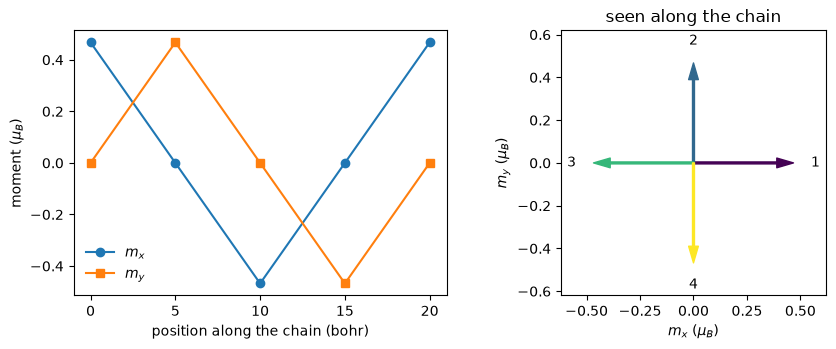

In [3]:
closed = np.vstack([moments, moments[:1]])
z = np.arange(len(closed)) * 5.0
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.6))
left.plot(z, closed[:, 0], 'o-', label='$m_x$')
left.plot(z, closed[:, 1], 's-', label='$m_y$')
left.set_xlabel('position along the chain (bohr)')
left.set_ylabel(r'moment ($\mu_B$)')
left.legend(frameon=False)
for site, m in enumerate(moments):
    right.annotate('', xy=(m[0], m[1]), xytext=(0, 0),
                   arrowprops=dict(width=1.4, headwidth=7, color=plt.cm.viridis(site / 3)))
    right.text(1.22 * m[0], 1.22 * m[1], f'{site + 1}', ha='center', va='center')
right.set_xlim(-0.62, 0.62)
right.set_ylim(-0.62, 0.62)
right.set_aspect('equal')
right.set_xlabel(r'$m_x$ ($\mu_B$)')
right.set_ylabel(r'$m_y$ ($\mu_B$)')
right.set_title('seen along the chain')
fig.tight_layout()

## A texture decides the symmetry of the crystal

A symmetry operation has to map the magnetic structure onto itself and not only
the positions. A moment is an axial vector, so a mirror or an inversion acts on
it differently from the way it acts on a position, and a texture that varies from
atom to atom rules out most of what the lattice alone would allow.

This is a physical constraint rather than bookkeeping. It decides which k-points
have to be sampled, and which components of the magnetization are allowed to be
nonzero at all. Stating a different texture on the same crystal gives a different
group, and `with_moments` is the way to state one without writing a new input
file.

In [4]:
textures = {'ferromagnet along z': [[0.0, 0.0, 0.6]] * 4,
            'ferromagnet along x': [[0.6, 0.0, 0.0]] * 4,
            'antiferromagnet along z': [[0.0, 0.0, 0.6], [0.0, 0.0, -0.6]] * 2}
print(f'{"magnetic structure":<26}{"operations":>11}')
for name, per_atom in textures.items():
    group = calc.with_moments(per_atom).calculation.symmetries
    print(f'{name:<26}{group.nsym:>11d}')
print(f'{"90 degree helix":<26}{calc.calculation.symmetries.nsym:>11d}')

magnetic structure         operations


ferromagnet along z                16


ferromagnet along x                 8


antiferromagnet along z            16
90 degree helix                     4


## Does the smaller group cost anything?

Those four operations are then used to fold the k-point sampling and to average
the density at every step, so if they were the wrong four the texture would be
averaged away and the calculation would converge cleanly to something else. The
check is to run the same cell with no symmetry at all and compare site by site.

In [5]:
free = Calculator.from_file('../tests/data/qe/h4-cycloid-90-nosym.in',
                            pseudo_dir='../tests/data/pseudo').get_scf()
free_moments = np.array(free.site_moments)
print(f'{"":>16}{"energy (Ry)":>16}{"|m| per site":>15}{"out of plane":>15}')
for label, scf, m in (('4 operations', result, moments),
                      ('no symmetry', free, free_moments)):
    print(f'{label:>16}{scf.total_energy:>16.10f}'
          f'{np.linalg.norm(m, axis=1).mean():>15.4f}{np.abs(m[:, 2]).max():>15.1e}')
print(f'\nthe two energies differ by '
      f'{abs(result.total_energy - free.total_energy):.1e} Ry')

                     energy (Ry)   |m| per site   out of plane
    4 operations   -3.8187943769         0.4675        2.8e-24
     no symmetry   -3.8187943871         0.4676        6.5e-06

the two energies differ by 1.0e-08 Ry


The two runs agree on the energy to 1e-8 Ry and on every site moment to 1e-4
$\mu_B$, so those four operations are the texture's own. They differ in one
place, and in the direction that favours symmetry: the component of the moment
out of the plane is a few times 1e-6 $\mu_B$ when nothing constrains it and 1e-24
with the four operations in force, because those operations forbid it exactly.
Symmetry buys exactness here rather than costing physics.

## Two numbers are needed to say a texture survived, not one

The site moments of this cell are a 4 by 3 matrix, and a natural test of whether
they still describe a helix is that the matrix has two comparable singular
values: the moments span a plane rather than a line. That test passes on a state
with no magnetism left at all, because it says nothing about scale.

Squeezing the same chain from 5 bohr to 3 bohr makes the point. Hydrogen at 3
bohr is not magnetic: the moments fall away as the calculation proceeds, and what
is left is a numerically perfect helix of essentially nothing.

In [6]:
def shape_and_size(scf):
    sigma = np.linalg.svd(np.array(scf.site_moments), compute_uv=False)
    start = np.linalg.svd(np.array(scf.history[0]['site_moments']), compute_uv=False)
    return sigma[1] / sigma[0], sigma[0] / start[0]

at = np.asarray(calc.system.cell.at)
squeezed = calc.with_cell(at * np.array([1.0, 1.0, 0.6])[:, None]).get_scf()
print(f'{"spacing":<10}{"planar":>10}{"size vs the first step":>25}{"|m| per site":>16}')
for label, scf in (('5 bohr', result), ('3 bohr', squeezed)):
    planar, size = shape_and_size(scf)
    moment = np.linalg.norm(np.array(scf.site_moments), axis=1).mean()
    print(f'{label:<10}{planar:>10.5f}{size:>25.2e}{moment:>16.2e}')

spacing       planar   size vs the first step    |m| per site
5 bohr       1.00000                 1.04e+00        4.68e-01
3 bohr       0.99849                 5.00e-04        5.25e-05


Both cells are planar to five digits and only one of them is a magnet. The pair
of numbers is what separates them: the shape, and the size the moments still have
compared with the size they had after the first step.


## What the moments start as decides which state is found

A converged magnetic state is the best starting guess there is for the next
calculation on the same cell, and that is also what makes it a trap: a
self-consistent loop settles into a state near the one it starts from, and
nothing in it turns a moment back towards the arrangement that was asked for. So
asking these four sites for a collinear antiferromagnet has two readings, and
they are two different calculations. The moments that are already there can be
carried over, or the new arrangement can be the one the run starts from.

The antiferromagnet has the 16 operations of the table above and the helix is not
invariant under them, so a helix carried into that run is averaged away on the
first step, and what converges is a chain with no moments left.


In [7]:
import warnings

afm = [[0.0, 0.0, 0.6], [0.0, 0.0, -0.6]] * 2
print(f'{"the moments start as":<22}{"iterations":>11}{"energy (Ry)":>16}'
      f'{"|m| per site":>14}{"m_z per site":>26}')
for label, start in (('the helix', 'auto'), ('the new card', 'seed')):
    with warnings.catch_warnings():
        # The carried run says out loud that the helix is not invariant under
        # the antiferromagnet's operations, which is what becomes of it.
        warnings.simplefilter('ignore')
        scf = calc.with_moments(afm, magnetization=start).get_scf()
    m = np.array(scf.site_moments)
    print(f'{label:<22}{scf.iterations:>11d}{scf.total_energy:>16.9f}'
          f'{np.linalg.norm(m, axis=1).mean():>14.4f}'
          f'{np.array2string(m[:, 2], precision=2, suppress_small=True):>26}')

the moments start as   iterations     energy (Ry)  |m| per site              m_z per site


the helix                      10    -3.816179461        0.0005             [0. 0. 0. 0.]


the new card                    9    -3.827162410        0.6008     [ 0.6 -0.6  0.6 -0.6]


The antiferromagnet that was asked for is the second row: 0.60 $\mu_B$ on every
site, alternating in sign, and **11.0 mRy below** the first. The first row is a
chain with no magnetism left, reached in ten iterations, and it reports
convergence exactly as confidently. Neither of the two numbers a calculation
prints at the end, the energy and the iteration count, says which of the two
questions was answered, and the run that found something else is not the slower
one by any rule: here it is the state with the moments in it that took fewer
iterations.

Carrying the moments is the right default where the new calculation is the same
magnet in a different regime, and it is the wrong one whenever the new
arrangement is the point, which is why `with_moments` starts from the card it was
given.


## What holds a texture that is not a minimum

Nothing in a self-consistent calculation turns a moment back towards where it was
asked to point. The helix above survives because it is a minimum of the energy
for this chain. A texture that is not a minimum drifts to whichever nearby
arrangement is lower and the calculation reports success: a two-atom chain of
the same kind, seeded 120 degrees apart, converges in ten iterations to 179.998
degrees, which is the collinear antiferromagnet.

Where the texture itself is the object of interest, a penalty on each atom's
moment holds it in place. `constrained_magnetization = 'atomic'` with the same
`STARTING_MOMENTS` card as its target is the one to use, with `lambda` setting
the stiffness; its energy is reported separately and is not part of the total, by
the same convention that keeps an external field's energy out.

A penalty is a term in the energy, so at convergence it is still pushing: the
angle that is left over is that push, and no choice of `lambda` removes it. The
other way to hold a texture is to apply a field on each atom and adjust it until
the moment sits exactly where it was asked to be, which is Elk's fixed spin
moment scheme resolved by atom (`constrained_magnetization = 'atomic fsm'`).
What converges is then a genuine stationary point of the unconstrained energy in
that field, and the field itself is a result: it is the torque the texture
costs.

Let us see the two side by side on a real magnet: two iron atoms of bcc iron,
asked to sit 90 degrees apart, where exchange wants them parallel.


In [8]:
text = open('../tests/data/qe/fe2-canted-nosoc.in').read().replace('nosym = .true.', "nosym = .true., constrained_magnetization = 'atomic fsm', lambda = 0.02")
held = Calculator.from_text(text + 'STARTING_MOMENTS\n 1.868 0 0\n 0 1.868 0\n', '../tests/data/pseudo', announce=False).get_scf(verbose=False, mixing_mode='adaptive', mixing_beta=0.05)
m = np.array(held.site_moments)
print(f'{held.iterations} iterations, {np.degrees(np.arccos(m[0] @ m[1] / np.prod(np.linalg.norm(m, axis=1)))):.3f} degrees apart, |m| = {np.linalg.norm(m, axis=1).round(4)} mu_B, field = {np.linalg.norm(np.asarray(held.magnetic_field.atomic), axis=1).round(4)} Ry')

46 iterations, 90.002 degrees apart, |m| = [1.868  1.8681] mu_B, field = [0.0264 0.0264] Ry


The field holds the pair at 90.00 degrees with both moments at the length they
were asked for. The penalty on the same cell, at `lambda = 1`, takes 76
iterations and leaves the pair at 89.2 degrees, 0.8 short, and it cannot be
made stiffer here, because at `lambda = 10` the calculation no longer
converges. The field that does it is about 0.026 Ry per atom, mostly
perpendicular to each moment, which is the exchange torque between the two
atoms read off directly. Elk, run on the same cell with the same scheme, holds
the same 90 degrees in 55 iterations under a field of 0.019 Ry. The field wants
a mixer with no memory of earlier iterations, which is why it is run with
`mixing_mode = 'adaptive'` and a small `mixing_beta`; the calculation warns if
it is not.

*The checks behind the numbers here live in
`tests/regression/test_a_vector_texture_survives.py` and
`tests/regression/test_holding_a_texture.py`.*